In [1]:
from pathlib import Path
import json
import pandas as pd
import re

# ===== CONFIG =====
ROOT_DIR = Path("../data/processed/ner_predictions/")
MANIFEST_PATH = Path("../data/processed/manifests/ner_manifest_mapped.jsonl")
LABELS_WHITELIST = True
PII_LABELS = {"PER", "LOC", "ORG"}

# ==================

In [2]:
# =========================
# HELPERS
# =========================
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def load_jsonl_df(path):
    return pd.DataFrame(load_jsonl(path))

def load_all_predictions(root_dir, excluded_dirs=None):
    all_rows = []
    for subdir in root_dir.iterdir():
        if not subdir.is_dir():
            continue

        if subdir.name not in excluded_dirs:
            continue

        for file in subdir.glob("*.jsonl"):
            model_name = file.stem
            data = load_jsonl(file)

            for row in data:
                row["model_name"] = model_name
                row["source_file"] = str(file.relative_to(root_dir))
                all_rows.append(row)

    return pd.DataFrame(all_rows)

def normalize_text(s):
    if pd.isna(s) or s is None:
        return None
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

# =========================
# LOAD
# =========================
manifest_df = load_jsonl_df(MANIFEST_PATH)
pred_df = load_all_predictions(ROOT_DIR, {"llm_prompted_ner", "speech_aware"})

In [3]:
# =========================
# EXPLODE GOLD
# =========================
def explode_manifest_entities(df):
    rows = []
    for _, row in df.iterrows():
        for ent in row.get("entities", []):
            rows.append({
                "segment_id": row["segment_id"],
                "meeting_id": row.get("meeting_id"),
                "speaker_id": row.get("speaker_id"),
                "text": row.get("text"),
                "entity_text": ent.get("text"),
                "entity_text_norm": normalize_text(ent.get("text")),
                "start_char": ent.get("start_char"),
                "end_char": ent.get("end_char"),
                "raw_label": ent.get("label"),
                "std_label": ent.get("std_label"),
            })
    return pd.DataFrame(rows)

In [4]:
# =========================
# EXPLODE PREDICTIONS
# =========================
LABEL_MAP = {
    "person": "PER",
    "location": "LOC",
    "company": "ORG",
    "date": "DATE",
    "time": "TIME",
    "money": "MONEY",
}

def explode_predictions(df):
    rows = []
    for _, row in df.iterrows():
        for ent in row.get("predicted_entities", []):
            raw_label = ent.get("label")
            mapped_label = LABEL_MAP.get(raw_label, raw_label)

            rows.append({
                "model_name": row["model_name"],
                "source_file": row.get("source_file"),
                "segment_id": row["segment_id"],
                "meeting_id": row.get("meeting_id"),
                "speaker_id": row.get("speaker_id"),
                "text": row.get("text"),
                "entity_text": ent.get("text"),
                "entity_text_norm": normalize_text(ent.get("text")),
                "start_char": ent.get("start_char"),
                "end_char": ent.get("end_char"),
                "raw_label": raw_label,
                "std_label": mapped_label,
                "score": ent.get("score"),
                "latency_ms": row.get("latency_ms"),
            })
    return pd.DataFrame(rows)

gold_entities_df = explode_manifest_entities(manifest_df)
pred_entities_df = explode_predictions(pred_df)


In [5]:
# =========================
# DEDUPLICATE
# =========================
gold_entities_df = gold_entities_df.drop_duplicates(
    subset=["segment_id", "start_char", "end_char", "std_label", "entity_text_norm"]
).copy()

pred_entities_df = pred_entities_df.drop_duplicates(
    subset=["model_name", "segment_id", "start_char", "end_char", "std_label", "entity_text_norm"]
).copy()

In [6]:
# =========================
# LABEL WHITELIST
# =========================
if LABELS_WHITELIST:
    gold_entities_eval_df = gold_entities_df[
        gold_entities_df["std_label"].isin(PII_LABELS)
    ].copy()

    pred_entities_eval_df = pred_entities_df[
        pred_entities_df["std_label"].isin(PII_LABELS)
    ].copy()
else:
    gold_entities_eval_df = gold_entities_df.copy()
    pred_entities_eval_df = pred_entities_df.copy()

print("Gold entities for eval:", gold_entities_eval_df.shape)
print("Pred entities for eval:", pred_entities_eval_df.shape)


Gold entities for eval: (1275, 10)
Pred entities for eval: (2889, 14)


In [7]:
# =========================
# 1) STRICT TYPED EVALUATION
# exact match on:
# segment_id + start_char + end_char + std_label
# =========================
def compute_strict_typed_metrics(gold_df, pred_df):
    gold_keys = gold_df[
        ["segment_id", "start_char", "end_char", "std_label"]
    ].drop_duplicates()

    results = []

    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[
            ["segment_id", "start_char", "end_char", "std_label"]
        ].drop_duplicates()

        tp = len(pred_keys.merge(
            gold_keys,
            on=["segment_id", "start_char", "end_char", "std_label"],
            how="inner"
        ))

        fp = len(pred_keys) - tp
        fn = len(gold_keys) - tp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        results.append({
            "model_name": model_name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

strict_df = compute_strict_typed_metrics(
    gold_entities_eval_df,
    pred_entities_eval_df
)

print("\nStrict typed metrics:")
display(strict_df)



Strict typed metrics:


,model_name,tp,fp,fn,precision,recall,f1
0,mistral_7b_predictions,89,314,1186,0.220844,0.069804,0.106079
1,llama3.1_8b_predictions,86,880,1189,0.089027,0.067451,0.076751
2,llama3.2_3b_predictions,72,839,1203,0.079034,0.056471,0.065874
3,qwen2.5_7b_predictions,42,28,1233,0.600000,0.032941,0.062454
4,gemma2_9b_predictions,40,10,1235,0.800000,0.031373,0.060377
5,whisper_base_bert_ner,10,384,1265,0.025381,0.007843,0.011983
6,smollm2_predictions,3,92,1272,0.031579,0.002353,0.004380


In [8]:
# =========================
# 2) RELAXED TEXT+LABEL EVALUATION
# match on:
# segment_id + normalized entity text + std_label
# =========================
def compute_text_label_metrics(gold_df, pred_df):
    gold_keys = gold_df[
        ["segment_id", "entity_text_norm", "std_label"]
    ].drop_duplicates()

    results = []

    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[
            ["segment_id", "entity_text_norm", "std_label"]
        ].drop_duplicates()

        tp = len(pred_keys.merge(
            gold_keys,
            on=["segment_id", "entity_text_norm", "std_label"],
            how="inner"
        ))

        fp = len(pred_keys) - tp
        fn = len(gold_keys) - tp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        results.append({
            "model_name": model_name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

relaxed_df = compute_text_label_metrics(
    gold_entities_eval_df,
    pred_entities_eval_df
)

print("\nRelaxed text+label metrics:")
display(relaxed_df)


Relaxed text+label metrics:


,model_name,tp,fp,fn,precision,recall,f1
0,mistral_7b_predictions,89,310,1186,0.223058,0.069804,0.106332
1,llama3.1_8b_predictions,86,815,1189,0.095450,0.067451,0.079044
2,whisper_base_bert_ner,57,268,1218,0.175385,0.044706,0.071250
3,llama3.2_3b_predictions,72,786,1203,0.083916,0.056471,0.067511
4,qwen2.5_7b_predictions,42,28,1233,0.600000,0.032941,0.062454
5,gemma2_9b_predictions,40,9,1235,0.816327,0.031373,0.060423
6,smollm2_predictions,3,88,1272,0.032967,0.002353,0.004392


In [9]:
# =========================
# RELAXED TEXT-ONLY EVALUATION
# match on:
# segment_id + normalized entity text
# =========================
def compute_text_only_metrics(gold_df, pred_df):
    gold_keys = gold_df[
        ["segment_id", "entity_text_norm"]
    ].drop_duplicates()

    results = []

    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[
            ["segment_id", "entity_text_norm"]
        ].drop_duplicates()

        tp = len(pred_keys.merge(
            gold_keys,
            on=["segment_id", "entity_text_norm"],
            how="inner"
        ))

        fp = len(pred_keys) - tp
        fn = len(gold_keys) - tp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        results.append({
            "model_name": model_name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

text_only_df = compute_text_only_metrics(
    gold_entities_eval_df,
    pred_entities_eval_df
)

print("\nText-only (no label) metrics:")
display(text_only_df)


Text-only (no label) metrics:


,model_name,tp,fp,fn,precision,recall,f1
0,mistral_7b_predictions,105,293,1170,0.263819,0.082353,0.125523
1,llama3.1_8b_predictions,96,793,1179,0.107987,0.075294,0.088725
2,llama3.2_3b_predictions,81,772,1194,0.094959,0.063529,0.076128
3,whisper_base_bert_ner,60,265,1215,0.184615,0.047059,0.075000
4,qwen2.5_7b_predictions,49,21,1226,0.700000,0.038431,0.072862
5,gemma2_9b_predictions,44,5,1231,0.897959,0.034510,0.066465
6,smollm2_predictions,3,86,1272,0.033708,0.002353,0.004399


In [13]:
# =========================
# CLEAN MODEL NAMES
# =========================
CLEAN_NAMES = {
    "gemma2_9b_predictions": "Gemma 2 (9B)",
    "llama3.1_8b_predictions": "LLaMA 3.1 (8B)",
    "llama3.2_3b_predictions": "LLaMA 3.2 (3B)",
    "mistral_7b_predictions": "Mistral (7B)",
    "qwen2.5_7b_predictions": "Qwen 2.5 (7B)",
    "smollm2_predictions": "SmolLM2",
    "tinyllama_predictions": "TinyLLaMA",
    "whisper_base_bert_ner": "Whisper + BERT",
}

# Apply clean names
strict_df["model"] = strict_df["model_name"].map(CLEAN_NAMES)

# Keep only needed columns + round
clean_metrics_df = (
    strict_df[["model", "precision", "recall", "f1"]]
    .copy()
    .round(3)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

print("\nCleaned strict metrics:")
display(clean_metrics_df)


Cleaned strict metrics:


,model,precision,recall,f1
0,Mistral (7B),0.221,0.070,0.106
1,LLaMA 3.1 (8B),0.089,0.067,0.077
2,LLaMA 3.2 (3B),0.079,0.056,0.066
3,Qwen 2.5 (7B),0.600,0.033,0.062
4,Gemma 2 (9B),0.800,0.031,0.060
5,Whisper + BERT,0.025,0.008,0.012
6,SmolLM2,0.032,0.002,0.004


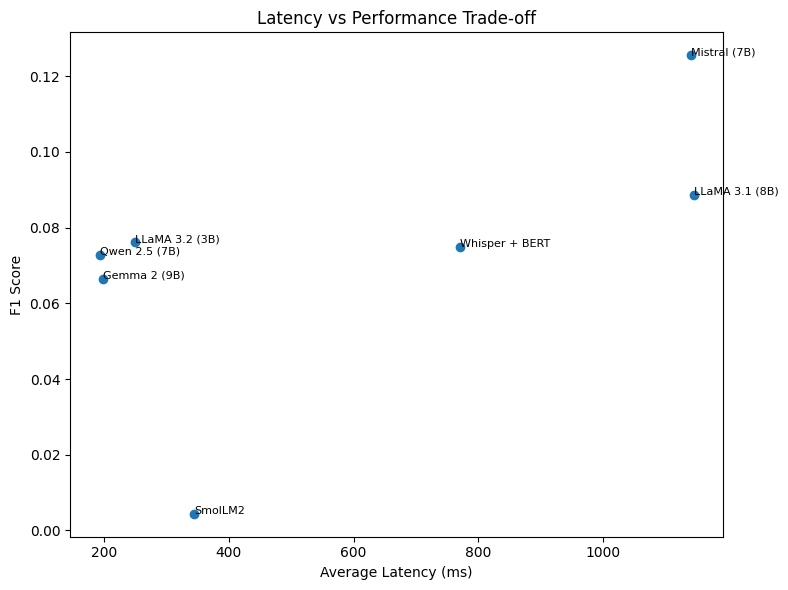

In [14]:
import matplotlib.pyplot as plt

# =========================
# LATENCY
# =========================
latency_df = (
    pred_df.groupby("model_name")["latency_ms"]
    .mean()
    .reset_index()
)

# =========================
# MERGE WITH F1
# =========================
merged = latency_df.merge(text_only_df, on="model_name")

# Clean names
merged["model"] = merged["model_name"].map(CLEAN_NAMES)

# Drop anything unmapped (e.g., excluded models)
merged = merged.dropna(subset=["model"])

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(merged["latency_ms"], merged["f1"])

# Add labels
for _, row in merged.iterrows():
    plt.text(row["latency_ms"], row["f1"], row["model"], fontsize=8)

plt.xlabel("Average Latency (ms)")
plt.ylabel("F1 Score")
plt.title("Latency vs Performance Trade-off")
plt.tight_layout()
plt.show()